device: cpu
torch: 2.10.0+cpu
torchvision: 0.25.0+cpu
STL10 already extracted: data\stl10_binary
Oxford-IIIT Pet already extracted: data\oxford-iiit-pet


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7160968..2.1872468].


classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
train: 5000 test: 8000
batch: torch.Size([32, 3, 96, 96]) torch.Size([32])


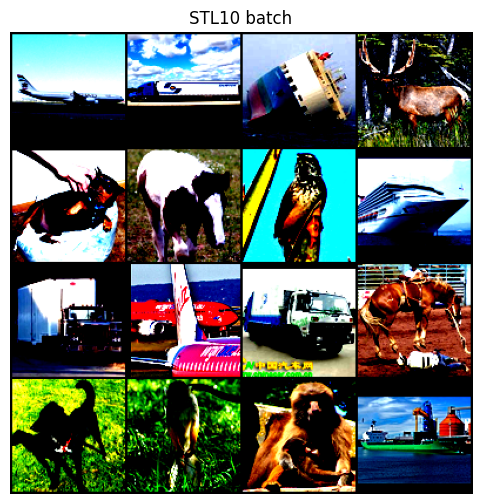

labels: [0, 9, 8, 4]
names: ['airplane', 'truck', 'ship', 'deer']


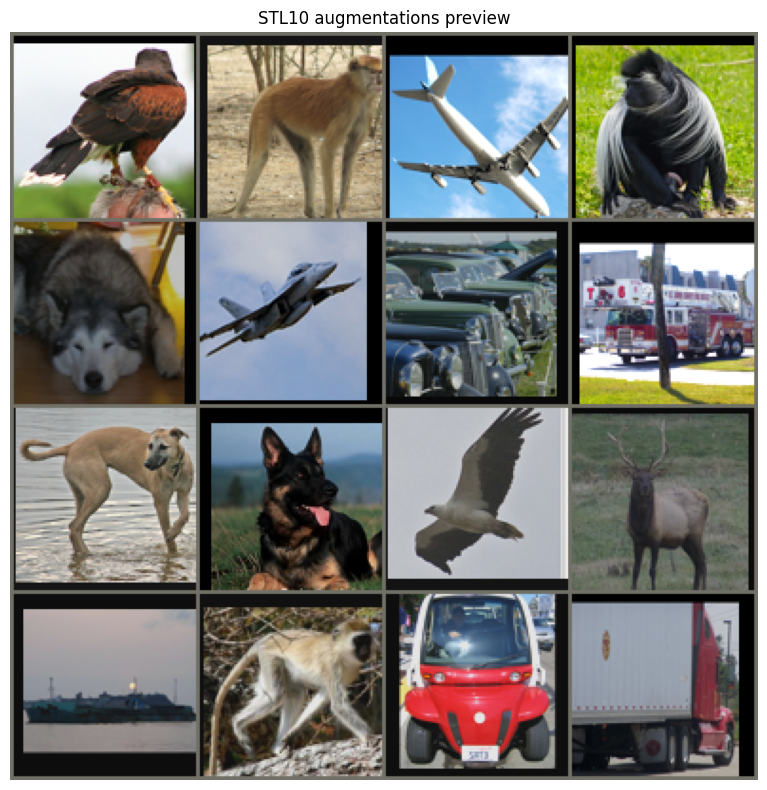

saved: artifacts\figures\augmentation_examples.png
[C1] epoch 01/2 | train_loss=1.8189 train_acc=0.3123 | val_loss=1.5400 val_acc=0.3949 | time=36.2s
[C1] epoch 02/2 | train_loss=1.3675 train_acc=0.4973 | val_loss=1.3395 val_acc=0.5090 | time=73.5s
saved row: C1
[C2] epoch 01/2 | train_loss=1.9155 train_acc=0.2843 | val_loss=1.5926 val_acc=0.4023 | time=52.4s
[C2] epoch 02/2 | train_loss=1.6000 train_acc=0.3970 | val_loss=1.5048 val_acc=0.4428 | time=22.7s
saved row: C2
[C3] epoch 01/1 | train_loss=1.4390 train_acc=0.5165 | val_loss=0.9153 val_acc=0.6963 | time=62.3s
saved row: C3
[C4] epoch 01/1 | train_loss=0.9613 train_acc=0.6803 | val_loss=0.5623 val_acc=0.8252 | time=46.8s
saved row: C4


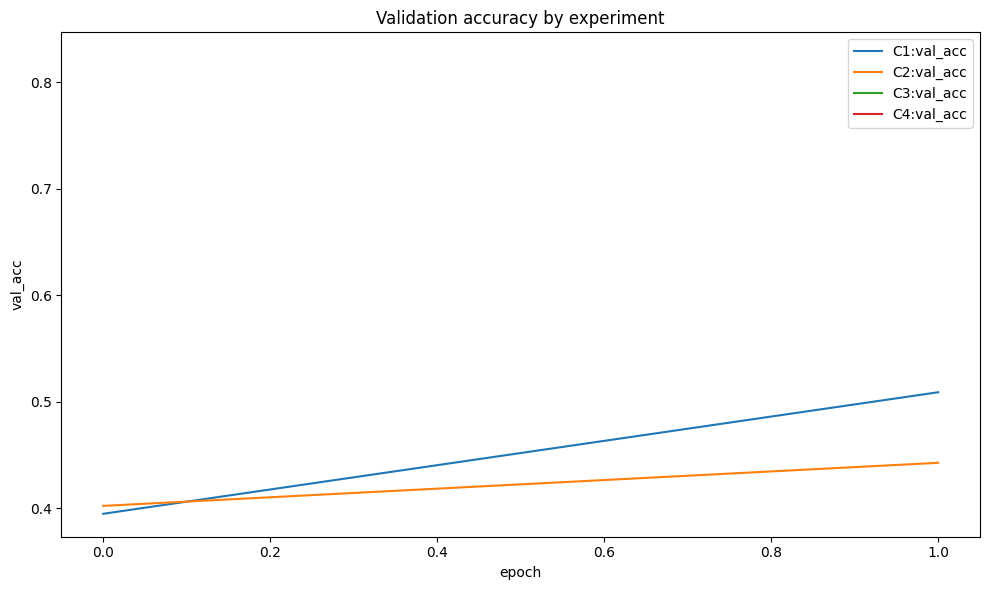

Best classification experiment: C4 0.8251953125
saved: artifacts\best_classifier.pt
saved: artifacts\best_classifier_config.json
Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to C:\Users\kiril/.cache\torch\hub\checkpoints\fcn_resnet50_coco-1167a1af.pth


URLError: <urlopen error [WinError 10061] Подключение не установлено, т.к. конечный компьютер отверг запрос на подключение>

In [11]:
import os
import json
import time
import csv
import tarfile
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

ROOT = Path(".")
ARTIFACTS = ROOT / "artifacts"
FIGURES = ARTIFACTS / "figures"
DATA_DIR = ROOT / "data"

ARTIFACTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

RUNS_CSV = ARTIFACTS / "runs.csv"
RUNS_FIELDS = [
    "experiment_id",
    "task",
    "dataset",
    "seed",
    "model_summary",
    "optimizer",
    "lr",
    "epochs_trained",
    "best_val_accuracy",
    "test_accuracy",
    "precision",
    "recall",
    "mean_iou",
    "notes",
]

def append_run(row: dict):
    expected_header = ",".join(RUNS_FIELDS)
    needs_header = True
    if RUNS_CSV.exists() and RUNS_CSV.stat().st_size > 0:
        with RUNS_CSV.open("r", encoding="utf-8") as f:
            first_line = f.readline().strip("\r\n")
        if first_line == expected_header:
            needs_header = False

    mode = "a" if not needs_header else "w"
    with RUNS_CSV.open(mode, newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=RUNS_FIELDS)
        if needs_header:
            writer.writeheader()
        writer.writerow(row)
        print("saved row:", row.get("experiment_id", "?"))

def ensure_stl10_local():
    archive_path = DATA_DIR / "stl10_binary.tar.gz"
    extracted_dir = DATA_DIR / "stl10_binary"

    if extracted_dir.exists() and (extracted_dir / "train_X.bin").exists():
        print("STL10 already extracted:", extracted_dir)
        return

    if not archive_path.exists():
        raise FileNotFoundError(f"Не найден архив STL10: {archive_path}")

    print("Распаковка STL10 из локального архива...")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=DATA_DIR)
    print("STL10 распакован в:", extracted_dir)

def ensure_oxford_pet_local():
    pet_root = DATA_DIR / "oxford-iiit-pet"
    images_dir = pet_root / "images"
    annotations_dir = pet_root / "annotations"
    images_archive = pet_root / "images.tar.gz"
    annotations_archive = pet_root / "annotations.tar.gz"

    if images_dir.exists() and annotations_dir.exists():
        print("Oxford-IIIT Pet already extracted:", pet_root)
        return

    if not images_archive.exists():
        raise FileNotFoundError(f"Не найден архив изображений Oxford-IIIT Pet: {images_archive}")
    if not annotations_archive.exists():
        raise FileNotFoundError(f"Не найден архив аннотаций Oxford-IIIT Pet: {annotations_archive}")

    print("Распаковка Oxford-IIIT Pet images...")
    with tarfile.open(images_archive, "r:gz") as tar:
        tar.extractall(path=pet_root)

    print("Распаковка Oxford-IIIT Pet annotations...")
    with tarfile.open(annotations_archive, "r:gz") as tar:
        tar.extractall(path=pet_root)

    print("Oxford-IIIT Pet распакован в:", pet_root)

ensure_stl10_local()
ensure_oxford_pet_local()

NUM_WORKERS = 0

def show_batch(images, labels=None, class_names=None, nrow=8, title=None):
    images = images.detach().cpu()
    grid = make_grid(images, nrow=nrow, padding=2)
    plt.figure(figsize=(12, 6))
    plt.axis("off")
    if title:
        plt.title(title)
    plt.imshow(grid.permute(1, 2, 0))
    plt.show()

    if labels is not None and class_names is not None:
        labels = labels.detach().cpu().tolist()
        print("labels:", labels[: min(len(labels), nrow)])
        print("names:", [class_names[i] for i in labels[: min(len(labels), nrow)]])

def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

@torch.no_grad()
def evaluate_classifier(model, loader, criterion):
    model.eval()
    losses = []
    accs = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits, y))
    return float(np.mean(losses)), float(np.mean(accs))

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    accs = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        accs.append(accuracy_from_logits(logits, y))
    return float(np.mean(losses)), float(np.mean(accs))

def fit_classifier(model, train_loader, val_loader, optimizer, criterion, epochs, exp_id, scheduler=None):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_state = None
    best_val_acc = -1.0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate_classifier(model, val_loader, criterion)

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"[{exp_id}] epoch {epoch:02d}/{epochs} | "
            f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
            f"val_loss={va_loss:.4f} val_acc={va_acc:.4f} | "
            f"time={time.time()-t0:.1f}s"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_acc

def plot_curves(histories: dict, metric: str, out_path: Path, title: str):
    plt.figure(figsize=(10, 6))
    for name, hist in histories.items():
        plt.plot(hist[metric], label=f"{name}:{metric}")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()

CLS_DATASET_NAME = "STL10"

cls_mean = (0.4467, 0.4398, 0.4066)
cls_std = (0.2603, 0.2566, 0.2713)

tfm_basic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cls_mean, cls_std),
])

tfm_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(96, padding=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(cls_mean, cls_std),
])

train_full_basic = torchvision.datasets.STL10(
    root=str(DATA_DIR),
    split="train",
    download=False,
    transform=tfm_basic,
)

train_full_aug = torchvision.datasets.STL10(
    root=str(DATA_DIR),
    split="train",
    download=False,
    transform=tfm_aug,
)

test_ds = torchvision.datasets.STL10(
    root=str(DATA_DIR),
    split="test",
    download=False,
    transform=tfm_basic,
)

num_classes = 10
class_names = train_full_basic.classes
print("classes:", class_names)
print("train:", len(train_full_basic), "test:", len(test_ds))

val_size = int(0.2 * len(train_full_basic))
train_size = len(train_full_basic) - val_size
g = torch.Generator().manual_seed(SEED)

train_basic, val_basic = random_split(train_full_basic, [train_size, val_size], generator=g)
train_aug, _ = random_split(train_full_aug, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

train_loader_basic = DataLoader(train_basic, batch_size=32, shuffle=True, num_workers=NUM_WORKERS)
train_loader_aug = DataLoader(train_aug, batch_size=32, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_basic, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

xb, yb = next(iter(train_loader_basic))
print("batch:", xb.shape, yb.shape)
show_batch(xb[:16], yb[:16], class_names, nrow=4, title="STL10 batch")

def denorm_stl(img):
    mean = torch.tensor(cls_mean).view(3, 1, 1)
    std = torch.tensor(cls_std).view(3, 1, 1)
    return img * std + mean

sample_ds = torchvision.datasets.STL10(
    root=str(DATA_DIR),
    split="train",
    download=False,
    transform=tfm_aug,
)
sample_loader = DataLoader(sample_ds, batch_size=16, shuffle=True, num_workers=0)
sample_imgs, sample_labels = next(iter(sample_loader))

grid = make_grid(sample_imgs, nrow=4, padding=2)
grid = denorm_stl(grid.cpu()).clamp(0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("STL10 augmentations preview")
plt.tight_layout()
aug_preview_path = FIGURES / "augmentation_examples.png"
plt.savefig(aug_preview_path, dpi=150)
plt.show()
print("saved:", aug_preview_path)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def build_resnet18_headonly(num_classes=10):
    weights = torchvision.models.ResNet18_Weights.DEFAULT
    model = torchvision.models.resnet18(weights=weights)
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def build_resnet18_finetune(num_classes=10):
    weights = torchvision.models.ResNet18_Weights.DEFAULT
    model = torchvision.models.resnet18(weights=weights)
    for name, p in model.named_parameters():
        if not name.startswith("layer4") and not name.startswith("fc"):
            p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

with RUNS_CSV.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=RUNS_FIELDS)
    writer.writeheader()

results_A = {}
criterion = nn.CrossEntropyLoss()

C1_EPOCHS = 2
C2_EPOCHS = 2
C3_EPOCHS = 1
C4_EPOCHS = 1

model_c1 = SimpleCNN(num_classes=num_classes).to(device)
opt_c1 = torch.optim.Adam(model_c1.parameters(), lr=1e-3)
hist_c1, best_val_c1 = fit_classifier(model_c1, train_loader_basic, val_loader, opt_c1, criterion, C1_EPOCHS, "C1")
_, test_acc_c1 = evaluate_classifier(model_c1, test_loader, criterion)
append_run({
    "experiment_id": "C1",
    "task": "classification",
    "dataset": CLS_DATASET_NAME,
    "seed": SEED,
    "model_summary": "SimpleCNN baseline",
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": C1_EPOCHS,
    "best_val_accuracy": round(best_val_c1, 4),
    "test_accuracy": round(test_acc_c1, 4),
    "precision": "",
    "recall": "",
    "mean_iou": "",
    "notes": "baseline",
})
results_A["C1"] = {"history": hist_c1, "best_val_acc": best_val_c1, "test_acc": test_acc_c1, "cfg": {"model": "SimpleCNN", "train": "basic"}}

model_c2 = SimpleCNN(num_classes=num_classes).to(device)
opt_c2 = torch.optim.Adam(model_c2.parameters(), lr=1e-3)
hist_c2, best_val_c2 = fit_classifier(model_c2, train_loader_aug, val_loader, opt_c2, criterion, C2_EPOCHS, "C2")
_, test_acc_c2 = evaluate_classifier(model_c2, test_loader, criterion)
append_run({
    "experiment_id": "C2",
    "task": "classification",
    "dataset": CLS_DATASET_NAME,
    "seed": SEED,
    "model_summary": "SimpleCNN + augmentation",
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": C2_EPOCHS,
    "best_val_accuracy": round(best_val_c2, 4),
    "test_accuracy": round(test_acc_c2, 4),
    "precision": "",
    "recall": "",
    "mean_iou": "",
    "notes": "augmentation",
})
results_A["C2"] = {"history": hist_c2, "best_val_acc": best_val_c2, "test_acc": test_acc_c2, "cfg": {"model": "SimpleCNN", "train": "aug"}}

model_c3 = build_resnet18_headonly(num_classes=num_classes).to(device)
opt_c3 = torch.optim.Adam(model_c3.parameters(), lr=1e-3)
hist_c3, best_val_c3 = fit_classifier(model_c3, train_loader_aug, val_loader, opt_c3, criterion, C3_EPOCHS, "C3")
_, test_acc_c3 = evaluate_classifier(model_c3, test_loader, criterion)
append_run({
    "experiment_id": "C3",
    "task": "classification",
    "dataset": CLS_DATASET_NAME,
    "seed": SEED,
    "model_summary": "ResNet18 pretrained head-only",
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": C3_EPOCHS,
    "best_val_accuracy": round(best_val_c3, 4),
    "test_accuracy": round(test_acc_c3, 4),
    "precision": "",
    "recall": "",
    "mean_iou": "",
    "notes": "transfer learning head-only",
})
results_A["C3"] = {"history": hist_c3, "best_val_acc": best_val_c3, "test_acc": test_acc_c3, "cfg": {"model": "resnet18_headonly", "train": "aug"}}

model_c4 = build_resnet18_finetune(num_classes=num_classes).to(device)
opt_c4 = torch.optim.Adam(filter(lambda p: p.requires_grad, model_c4.parameters()), lr=1e-4)
hist_c4, best_val_c4 = fit_classifier(model_c4, train_loader_aug, val_loader, opt_c4, criterion, C4_EPOCHS, "C4")
_, test_acc_c4 = evaluate_classifier(model_c4, test_loader, criterion)
append_run({
    "experiment_id": "C4",
    "task": "classification",
    "dataset": CLS_DATASET_NAME,
    "seed": SEED,
    "model_summary": "ResNet18 fine-tune layer4+fc",
    "optimizer": "Adam",
    "lr": 1e-4,
    "epochs_trained": C4_EPOCHS,
    "best_val_accuracy": round(best_val_c4, 4),
    "test_accuracy": round(test_acc_c4, 4),
    "precision": "",
    "recall": "",
    "mean_iou": "",
    "notes": "fine-tuning",
})
results_A["C4"] = {"history": hist_c4, "best_val_acc": best_val_c4, "test_acc": test_acc_c4, "cfg": {"model": "resnet18_finetune", "train": "aug"}}

plot_curves(
    {k: {"val_acc": v["history"]["val_acc"]} for k, v in results_A.items()},
    "val_acc",
    FIGURES / "classification_val_accuracy.png",
    "Validation accuracy by experiment",
)

best_id = max(results_A.keys(), key=lambda k: results_A[k]["best_val_acc"])
print("Best classification experiment:", best_id, results_A[best_id]["best_val_acc"])

if best_id in ["C1", "C2"]:
    best_model = SimpleCNN(num_classes=num_classes).to(device)
elif best_id == "C3":
    best_model = build_resnet18_headonly(num_classes=num_classes).to(device)
else:
    best_model = build_resnet18_finetune(num_classes=num_classes).to(device)

if best_id == "C1":
    best_model.load_state_dict(model_c1.state_dict())
elif best_id == "C2":
    best_model.load_state_dict(model_c2.state_dict())
elif best_id == "C3":
    best_model.load_state_dict(model_c3.state_dict())
else:
    best_model.load_state_dict(model_c4.state_dict())

best_classifier_path = ARTIFACTS / "best_classifier.pt"
torch.save(best_model.state_dict(), best_classifier_path)

best_classifier_config = {
    "seed": SEED,
    "dataset": CLS_DATASET_NAME,
    "best_experiment_id": best_id,
    "model": results_A[best_id]["cfg"]["model"],
    "training_setup": results_A[best_id]["cfg"]["train"],
    "best_val_accuracy": results_A[best_id]["best_val_acc"],
    "test_accuracy": results_A[best_id]["test_acc"],
}
best_classifier_config_path = ARTIFACTS / "best_classifier_config.json"
best_classifier_config_path.write_text(json.dumps(best_classifier_config, indent=2, ensure_ascii=False), encoding="utf-8")

print("saved:", best_classifier_path)
print("saved:", best_classifier_config_path)

SEG_DATASET_NAME = "OxfordIIITPet"

seg_img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

class OxfordPetBinarySegmentation(torch.utils.data.Dataset):
    def __init__(self, root, split="test"):
        self.ds = torchvision.datasets.OxfordIIITPet(
            root=str(root),
            split=split,
            target_types="segmentation",
            download=False,
            transform=seg_img_transform,
        )
        self.mask_resize = transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST)
        self.mask_to_tensor = transforms.PILToTensor()

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, mask = self.ds[idx]
        mask = self.mask_resize(mask)
        mask = self.mask_to_tensor(mask).squeeze(0).long()
        binary_mask = (mask == 1).long()
        return img, binary_mask

seg_test_ds = OxfordPetBinarySegmentation(DATA_DIR, split="test")
seg_test_loader = DataLoader(seg_test_ds, batch_size=4, shuffle=False, num_workers=0)

seg_weights = torchvision.models.segmentation.FCN_ResNet50_Weights.DEFAULT
seg_model = torchvision.models.segmentation.fcn_resnet50(weights=seg_weights).to(device)
seg_model.eval()

@torch.no_grad()
def segmentation_metrics_binary(pred_mask, gt_mask):
    pred = pred_mask.bool()
    gt = gt_mask.bool()

    tp = (pred & gt).sum().item()
    fp = (pred & ~gt).sum().item()
    fn = (~pred & gt).sum().item()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    return precision, recall, iou

@torch.no_grad()
def evaluate_segmentation(model, loader, max_batches=5):
    precisions = []
    recalls = []
    ious = []

    for bi, (x, y) in enumerate(loader):
        x = x.to(device)
        y = y.to(device)

        out = model(x)["out"]
        pred_classes = out.argmax(dim=1)
        pred_binary = pred_classes > 0

        for i in range(x.size(0)):
            p, r, j = segmentation_metrics_binary(pred_binary[i], y[i])
            precisions.append(p)
            recalls.append(r)
            ious.append(j)

        if max_batches is not None and (bi + 1) >= max_batches:
            break

    return float(np.mean(precisions)), float(np.mean(recalls)), float(np.mean(ious))

precision, recall, mean_iou = evaluate_segmentation(seg_model, seg_test_loader, max_batches=5)
print("Segmentation metrics:")
print("precision:", precision)
print("recall:", recall)
print("mean_iou:", mean_iou)

append_run({
    "experiment_id": "S1",
    "task": "segmentation",
    "dataset": SEG_DATASET_NAME,
    "seed": SEED,
    "model_summary": "FCN-ResNet50 pretrained, binary pet-vs-background",
    "optimizer": "",
    "lr": "",
    "epochs_trained": 0,
    "best_val_accuracy": "",
    "test_accuracy": "",
    "precision": round(precision, 4),
    "recall": round(recall, 4),
    "mean_iou": round(mean_iou, 4),
    "notes": "evaluation-only",
})

xb_seg, yb_seg = next(iter(seg_test_loader))
with torch.no_grad():
    pred_seg = seg_model(xb_seg.to(device))["out"].argmax(dim=1).cpu() > 0

n_show = min(3, xb_seg.size(0))
fig, axes = plt.subplots(n_show, 3, figsize=(10, 3 * n_show))
if n_show == 1:
    axes = np.expand_dims(axes, 0)

for i in range(n_show):
    img = xb_seg[i].permute(1, 2, 0).numpy()
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(yb_seg[i].numpy(), cmap="gray")
    axes[i, 1].set_title("GT binary mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred_seg[i].numpy(), cmap="gray")
    axes[i, 2].set_title("Pred binary mask")
    axes[i, 2].axis("off")

plt.tight_layout()
seg_example_path = FIGURES / "segmentation_examples.png"
plt.savefig(seg_example_path, dpi=150)
plt.show()
print("saved:", seg_example_path)

report_path = ROOT / "report.md"
if report_path.exists():
    txt = report_path.read_text(encoding="utf-8")
    txt = txt.replace("{{BEST_CLASSIFIER_ID}}", str(best_id))
    txt = txt.replace("{{BEST_CLASSIFIER_VAL_ACC}}", f"{results_A[best_id]['best_val_acc']:.4f}")
    txt = txt.replace("{{BEST_CLASSIFIER_TEST_ACC}}", f"{results_A[best_id]['test_acc']:.4f}")
    txt = txt.replace("{{SEG_PRECISION}}", f"{precision:.4f}")
    txt = txt.replace("{{SEG_RECALL}}", f"{recall:.4f}")
    txt = txt.replace("{{SEG_MIOU}}", f"{mean_iou:.4f}")
    report_path.write_text(txt, encoding="utf-8")
    print("Updated placeholders in report.md")

print("Done. Artifacts saved in:", ARTIFACTS.resolve())
print("Figures saved in:", FIGURES.resolve())